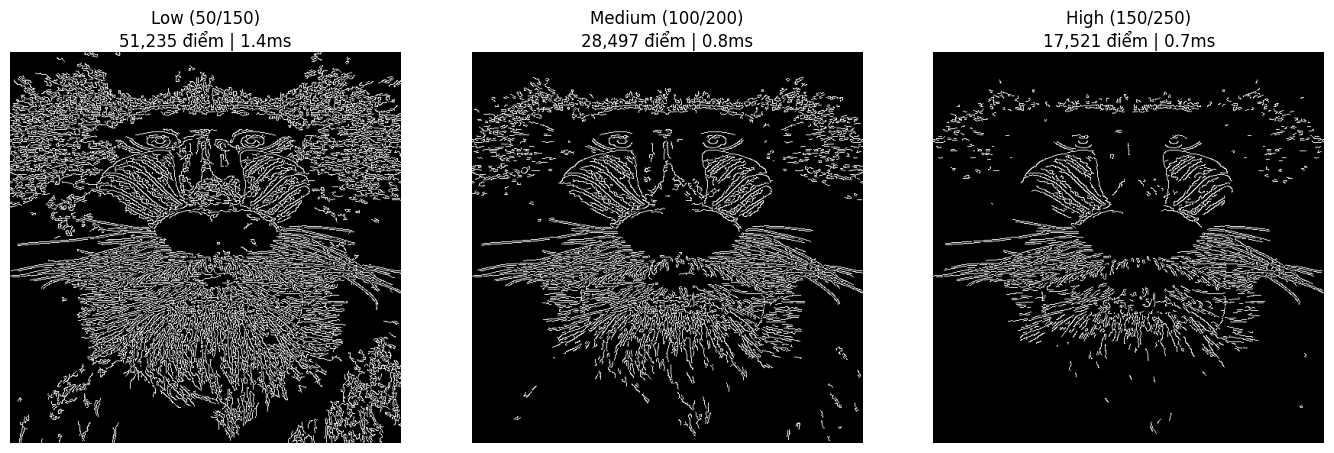

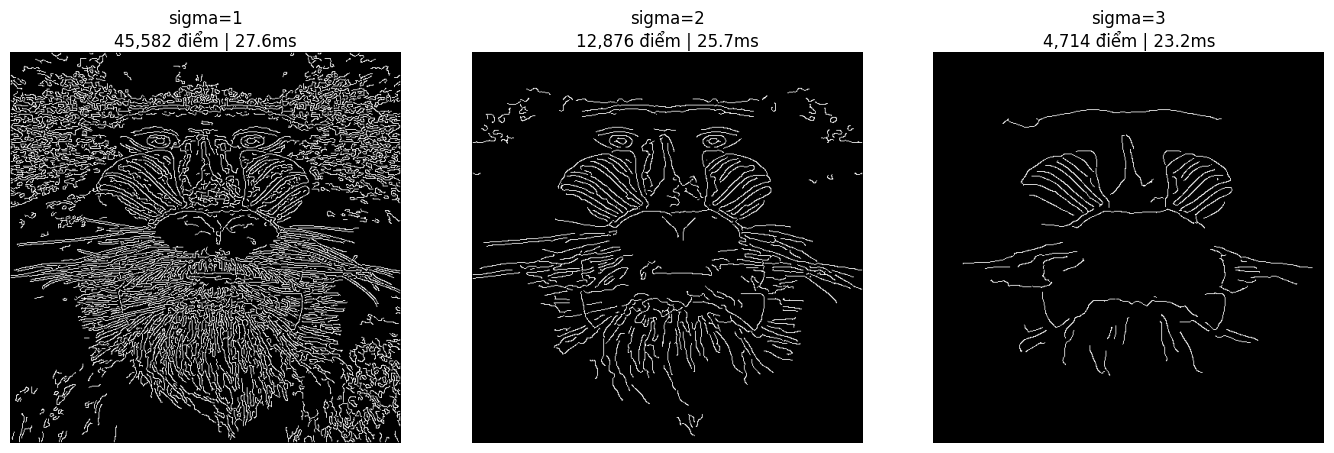

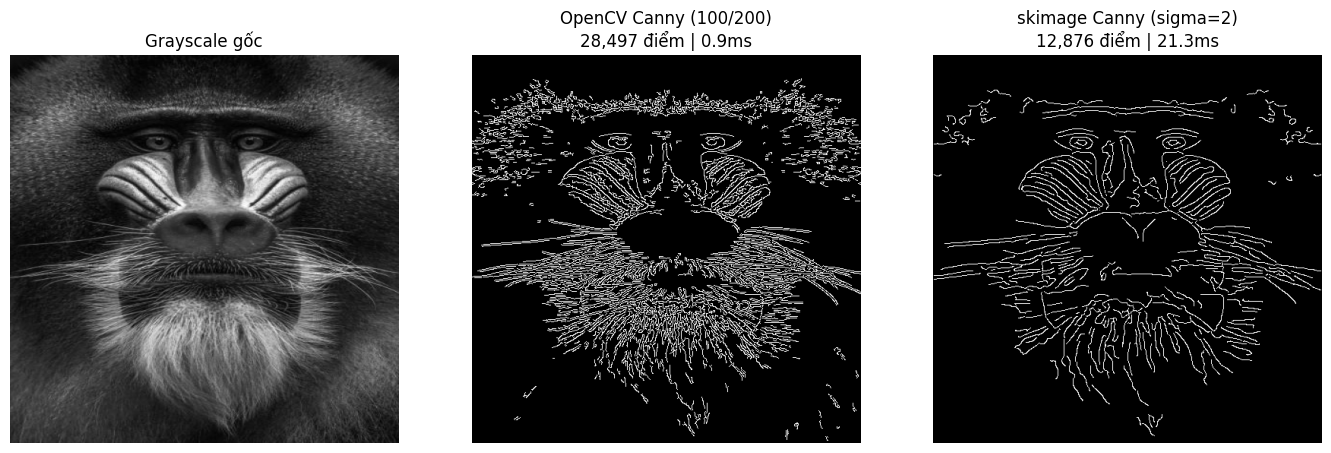

In [ ]:
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.feature import canny as skimage_canny

img_bgr = cv2.imread("../input/lab_image.jpg")
if img_bgr is None:
    raise FileNotFoundError("Không tìm thấy ảnh tại ../input/lab_image.jpg")

img_bgr = cv2.resize(img_bgr, (512, 512), interpolation=cv2.INTER_AREA)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
gray_f = img_gray.astype(np.float64) / 255.0


fig1, axes1 = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (lo, hi, lbl) in zip(axes1, [(50, 150, "Low (50/150)"),
                                     (100, 200, "Medium (100/200)"),
                                     (150, 250, "High (150/250)")]):
    # Tính thời gian để so 
    t0 = time.perf_counter()
    edge = cv2.Canny(img_gray, lo, hi)
    t = (time.perf_counter() - t0) * 1000
    
    pts = int(np.sum(edge > 0))
    ax.imshow(edge, cmap='gray')
    ax.set_title(f"{lbl}\n{pts:,} điểm | {t:.1f}ms", pad=4)
    ax.axis("off")

plt.tight_layout()
plt.show()

#  So giữa sigma 1,2,3
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, sigma in zip(axes2, [1, 2, 3]):
    # Tính thời gian trực tiếp
    t0 = time.perf_counter()
    edge = skimage_canny(gray_f, sigma=sigma)
    t = (time.perf_counter() - t0) * 1000
    # tính các điểm cạnh để so sánh với những ảnh khác
    pts = int(np.sum(edge))
    ax.imshow(edge.astype(np.uint8) * 255, cmap='gray')
    ax.set_title(f"sigma={sigma}\n{pts:,} điểm | {t:.1f}ms", pad=4)
    ax.axis("off")

plt.tight_layout()
plt.show()

#SO SÁNH giữa medium canny với sigma2 
fig3, axes3 = plt.subplots(1, 3, figsize=(14, 4.5))

# Đo thời gian thực thi của OpenCV Canny
t0 = time.perf_counter()
e_cv2 = cv2.Canny(img_gray, 100, 200)
t1 = (time.perf_counter() - t0) * 1000

# Đo skimage Canny
t0 = time.perf_counter()
e_ski = skimage_canny(gray_f, sigma=2)
t2 = (time.perf_counter() - t0) * 1000
axes3[0].imshow(img_gray, cmap='gray')
axes3[0].set_title("Grayscale gốc")
axes3[0].axis("off")

axes3[1].imshow(e_cv2, cmap='gray')
axes3[1].set_title(f"OpenCV Canny (100/200)\n{int(np.sum(e_cv2 > 0)):,} điểm | {t1:.1f}ms")
axes3[1].axis("off")

axes3[2].imshow(e_ski.astype(np.uint8) * 255, cmap='gray')
axes3[2].set_title(f"skimage Canny (sigma=2)\n{int(np.sum(e_ski)):,} điểm | {t2:.1f}ms")
axes3[2].axis("off")

plt.tight_layout()
plt.show()